In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import pandas as pd

In [26]:
 
# Load the Excel file
file_path = "data/Individual_Annotations.xlsx"

# Read the first sheet
df = pd.read_excel(file_path)

In [34]:
# Count Synthetic, Real, or Both occurrences

synthetic_count = (
    df["Data"]
    .dropna()
    .str.contains(r"Synthetic", case=False, regex=True)
    .sum()
)

real_count = (
    df["Data"]
    .dropna()
    .str.contains(r"Real", case=False, regex=True)
    .sum()
)

both_count = (
    df["Data"]
    .dropna()
    .str.contains(r"Both", case=False, regex=True)
    .sum()
)

print("Synthetic count:", synthetic_count)
print("Real count:", real_count)
print("Both count:", both_count)

Synthetic count: 34
Real count: 2
Both count: 6


In [28]:
# Count TensorFlow and PyTorch occurrences

tensorflow_count = (
    df["ML framework"]
    .dropna()
    .str.contains(r"TensorFlow", case=False, regex=True)
    .sum()
)

pytorch_count = (
    df["ML framework"]
    .dropna()
    .str.contains(r"PyTorch|Pytorch", case=False, regex=True)
    .sum()
)

print("TensorFlow count:", tensorflow_count)
print("PyTorch count:", pytorch_count)

TensorFlow count: 6
PyTorch count: 16


In [31]:
# Count FD and SEM occurrences

fd_count = (
    df["Standard method"]
    .dropna()
    .str.contains(r"\bFD\b|Finite Difference", case=False, regex=True)
    .sum()
)

sem_count = (
    df["Standard method"]
    .dropna()
    .str.contains(r"\bSEM\b|Spectral Element", case=False, regex=True)
    .sum()
)

print("FD count:", fd_count)
print("SEM count:", sem_count)

FD count: 30
SEM count: 4


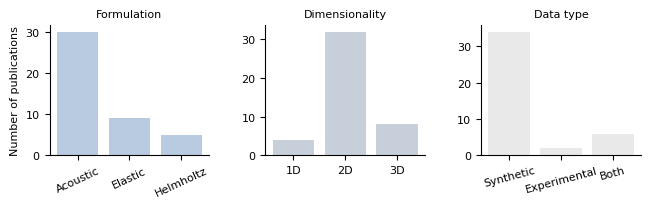

In [39]:
# Colors
color_blue = '#b9cbe0ff'
color_blue_2 = '#c7d0daff'
color_gray = '#d6d6d683'

#  Invented counts 
wave_eq_labels = ["Acoustic", "Elastic", "Helmholtz"]
wave_eq_counts = [30, 9, 5]

dim_labels = ["1D", "2D", "3D"]
dim_counts = [4, 32, 8]

data_labels = ["Synthetic", "Experimental", "Both"]
data_counts = [synthetic_count, real_count, both_count]

#  Figure
fig = plt.figure(figsize=(6.5, 2.0))
gs = GridSpec(1, 3, width_ratios=[1, 1, 1], figure=fig)

fig.subplots_adjust(
    left=0.07,
    right=0.98,
    bottom=0.30,
    top=0.95,
    wspace=0.35
)

# Panel 1: Wave equation 
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(wave_eq_labels, wave_eq_counts, color=color_blue)

ax1.set_title("Formulation", fontsize=8)
ax1.set_ylabel("Number of publications", fontsize=8)
ax1.tick_params(axis='x', rotation=25, labelsize=8)
ax1.tick_params(axis='y', labelsize=8)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

#  Panel 2: Dimensionality 
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(dim_labels, dim_counts, color=color_blue_2)

ax2.set_title("Dimensionality", fontsize=8)
#ax2.set_xlabel("Dimensions", fontsize=8)
ax2.tick_params(axis='both', labelsize=8)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Panel 3: Data type 
ax3 = fig.add_subplot(gs[0, 2])
ax3.bar(data_labels, data_counts, color=color_gray)

ax3.set_title("Data type", fontsize=8)
ax3.tick_params(axis='x', rotation=15, labelsize=8)
ax3.tick_params(axis='y', labelsize=8)

ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

#  Save
plt.savefig(
    "figs/equation_dimensionality_data_type.svg",
    dpi=300,
    bbox_inches="tight"
)
plt.savefig(
    "figs/equation_dimensionality_data_type.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

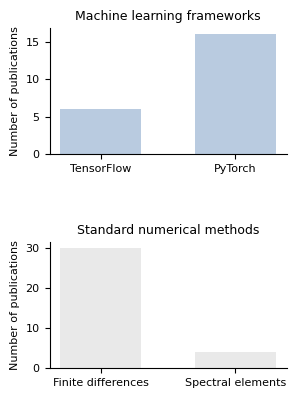

In [ ]:
# =========================
# Colors
# =========================
color_ml = '#b9cbe0ff'
color_standard = '#d6d6d683'

# =========================
# Example counts
# Replace with your values
# =========================

# Machine learning frameworks
ml_labels = ["TensorFlow", "PyTorch"]
ml_counts = [tensorflow_count, pytorch_count]

# Standard numerical methods
std_labels = ["Finite differences", "Spectral elements"]
std_counts = [fd_count, sem_count]

# =========================
# Figure layout
# 1 column × 2 rows
# =========================
fig = plt.figure(figsize=(3.0, 4.0))

gs = GridSpec(
    2, 1,
    height_ratios=[1, 1],
    figure=fig
)

fig.subplots_adjust(
    left=0.18,
    right=0.97,
    bottom=0.10,
    top=0.95,
    hspace=0.7
)

# =========================
# Panel 1: ML frameworks
# =========================
ax1 = fig.add_subplot(gs[0, 0])

ax1.bar(
    ml_labels,
    ml_counts,
    color=color_ml,
    width=0.6
)

ax1.set_title("Machine learning frameworks", fontsize=9)
ax1.set_ylabel("Number of publications", fontsize=8)

ax1.tick_params(axis='x', labelsize=8)
ax1.tick_params(axis='y', labelsize=8)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# =========================
# Panel 2: Standard methods
# =========================
ax2 = fig.add_subplot(gs[1, 0])

ax2.bar(
    std_labels,
    std_counts,
    color=color_standard,
    width=0.6
)

ax2.set_title("Standard numerical methods", fontsize=9)
ax2.set_ylabel("Number of publications", fontsize=8)

ax2.tick_params(axis='x', labelsize=8)
ax2.tick_params(axis='y', labelsize=8)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# =========================
# Save figure
# =========================
plt.savefig(
    "figs/frameworks_methods.svg",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "figs/frameworks_methods.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()